# Bit Coin Price Prdiction main Notebook

# Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import xgboost as xgb
import ta

print("TensorFlow:", tf.__version__)
print("Libraries loaded successfully")

TensorFlow: 2.16.1
Libraries loaded successfully


In [29]:
# For Evalution we will use these library

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, explained_variance_score, r2_score
from sklearn.preprocessing import MinMaxScaler

# For model building we will use these library
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, GRU
from tensorflow.keras.optimizers import Adam

# For PLotting we will use these library

import matplotlib.pyplot as plt
from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Data Loading

In [30]:
# main bitcoin data
maindf = pd.read_csv('dataset_upto_20august.csv')

In [31]:
maindf.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00+00:00,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00+00:00,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00+00:00,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00+00:00,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00+00:00,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [32]:
print('Total number of days present in the dataset: ',maindf.shape[0])
print('Total number of fields present in the dataset: ',maindf.shape[1])
print('Shape of main data : ',maindf.shape)

Total number of days present in the dataset:  3154
Total number of fields present in the dataset:  12
Shape of main data :  (3154, 12)


In [33]:
maindf.columns

Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')

In [34]:
# Open and close time is same and ignore has 0 values only
df = maindf.drop(columns=['Ignore','Close time'])

# Adding New featuresn Data 

In [35]:
dxy   = pd.read_csv('DXY_clean.csv')
vix   = pd.read_csv('VIX.csv')
sp500 = pd.read_csv('SP500.csv')
gold  = pd.read_csv('Gold.csv')

In [36]:
print(dxy.shape, vix.shape, sp500.shape, gold.shape)
print(dxy.head())
print(vix.head())

(2173, 3) (2172, 2) (2171, 2) (2172, 2)
   Unnamed: 0        Date        DXY
0           0  2018-01-02  91.849998
1           1  2018-01-03  92.160004
2           2  2018-01-04  91.849998
3           3  2018-01-05  91.949997
4           4  2018-01-08  92.330002
         Date   VIX
0  2018-01-02  9.77
1  2018-01-03  9.15
2  2018-01-04  9.22
3  2018-01-05  9.22
4  2018-01-08  9.52


# Data Cleaning and Merging

In [38]:
# Clean + normalize dates
df['Date'] = pd.to_datetime(df['Open time'], utc=True).dt.tz_localize(None).dt.normalize()

for x in [dxy, vix, sp500, gold]:
    x['Date'] = pd.to_datetime(x['Date'], utc=True).dt.tz_localize(None).dt.normalize()

# Remove unnecessary DXY index column
dxy = dxy.drop(columns=['Unnamed: 0'], errors='ignore')

# Merge external features
df = df.merge(dxy, on='Date', how='left')
df = df.merge(vix, on='Date', how='left')
df = df.merge(sp500, on='Date', how='left')
df = df.merge(gold, on='Date', how='left')

# Fill missing market-day values
ext = ['DXY', 'VIX', 'SP500', 'Gold']
df[ext] = df[ext].ffill()

# Remove remaining missing values
df = df.dropna(subset=ext).reset_index(drop=True)

print("Shape:", df.shape)
print(df[['Date', 'Close', 'DXY', 'VIX', 'SP500', 'Gold']].head())
print("\nMissing values:")
print(df[ext].isna().sum())

Shape: (3153, 15)
        Date     Close        DXY   VIX        SP500         Gold
0 2018-01-02  14675.11  91.849998  9.77  2695.810059  1313.699951
1 2018-01-03  14919.51  92.160004  9.15  2713.060059  1316.199951
2 2018-01-04  15059.54  91.849998  9.22  2723.989990  1319.400024
3 2018-01-05  16960.39  91.949997  9.22  2743.149902  1320.300049
4 2018-01-06  17069.79  91.949997  9.22  2743.149902  1320.300049

Missing values:
DXY      0
VIX      0
SP500    0
Gold     0
dtype: int64


In [110]:
df.shape

(3120, 27)

# EDA 

## Bitcoin Price trend (2018 - 2026)

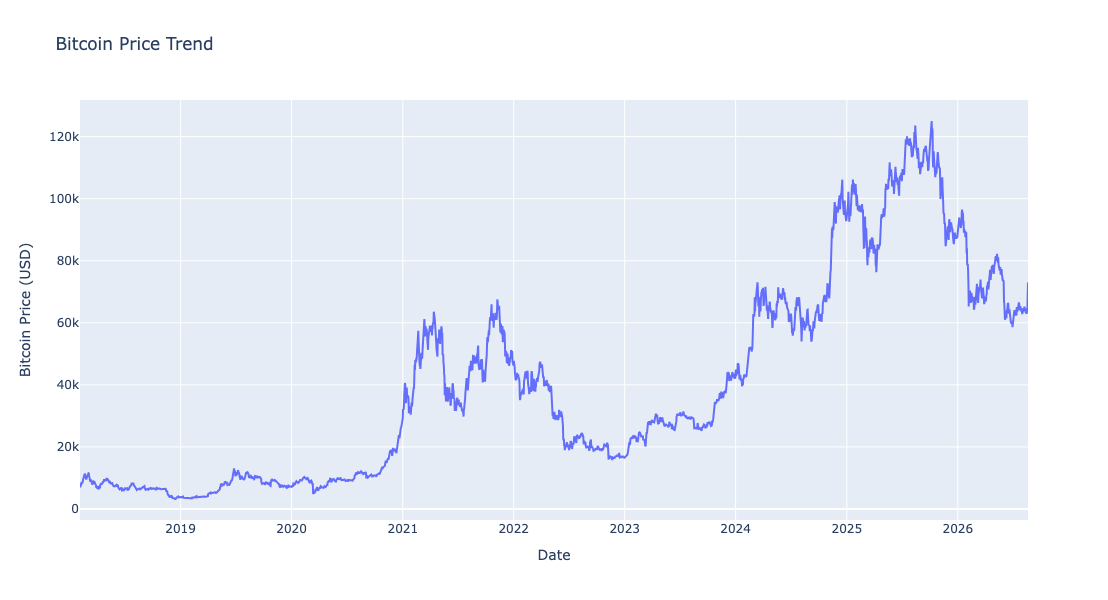

In [81]:
# exact data 1 Jan 2018 - 20 August 2026

import plotly.graph_objects as go

f=go.Figure()
f.add_trace(go.Scatter(x=df['Date'],y=df['Close'],name='Bitcoin'))
f.update_layout(title='Bitcoin Price Trend',xaxis_title='Date',
                yaxis_title='Bitcoin Price (USD)',
                hovermode='x unified',width=1100,height=600)
f.show()

## Daily Returns + Volatility

### Meaning 

Daily Return shows how much Bitcoin’s price changes in one day.    

Positive return → price increased     
Negative return → price decreased      
Large spikes → high volatility     
Small fluctuations → relatively stable market      

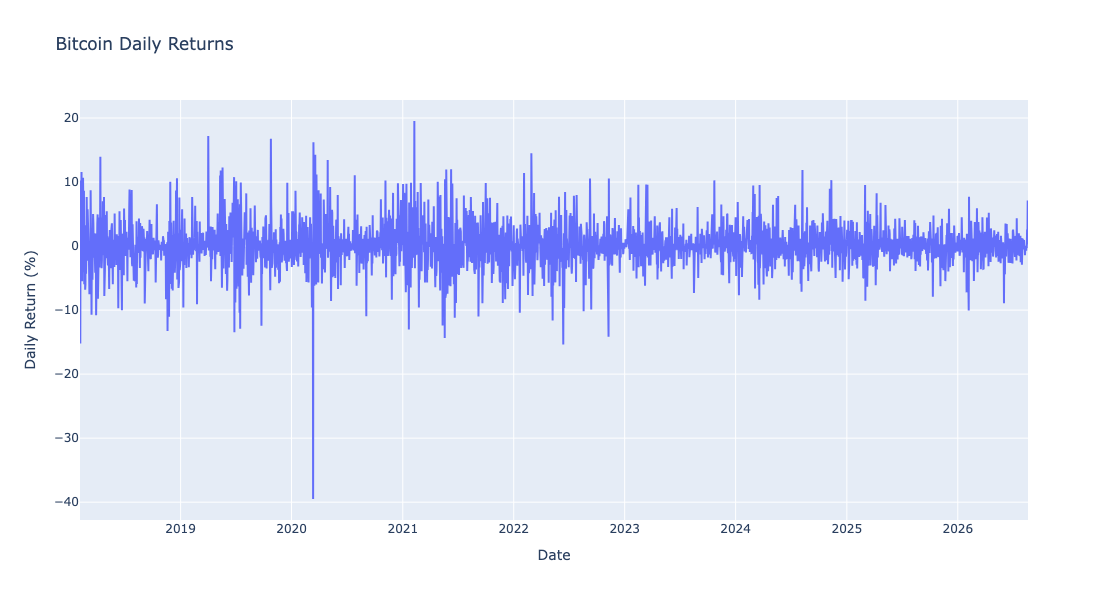

In [83]:
import plotly.graph_objects as go

d=df[['Date','Close']].copy()
d['Daily_Return']=d['Close'].pct_change()*100

f=go.Figure()
f.add_trace(go.Scatter(x=d['Date'],y=d['Daily_Return'],name='Daily Return'))
f.update_layout(title='Bitcoin Daily Returns',xaxis_title='Date',
                yaxis_title='Daily Return (%)',
                hovermode='x unified',width=1100,height=600)
f.show()

### Short Report 
The daily return graph shows that Bitcoin has high volatility, with most returns fluctuating around 0%. Several large positive and negative spikes indicate periods of sudden price movements. This volatility makes Bitcoin price prediction challenging and justifies the use of LSTM-based time-series forecasting.

## Trading Volume Vs Bitcoin Price

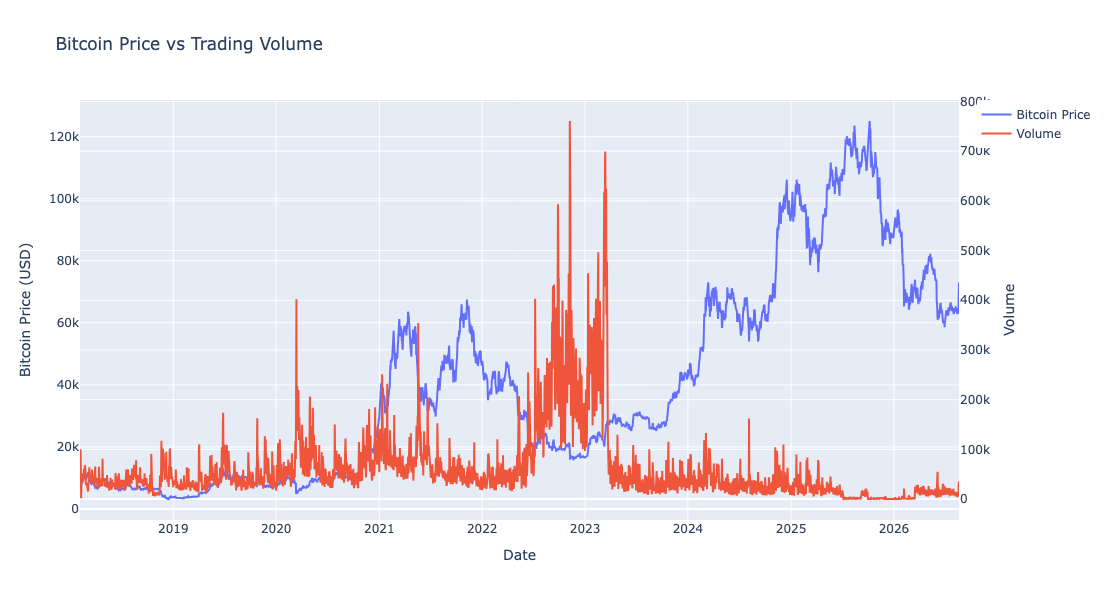

In [85]:
f=go.Figure()
f.add_scatter(x=df['Date'],y=df['Close'],name='Bitcoin Price')
f.add_scatter(x=df['Date'],y=df['Volume'],name='Volume',yaxis='y2')
f.update_layout(title='Bitcoin Price vs Trading Volume',
                xaxis_title='Date',
                yaxis_title='Bitcoin Price (USD)',
                yaxis2=dict(title='Volume',overlaying='y',side='right'),
                hovermode='x unified',width=1100,height=600)
f.show()

## Short Report

Bitcoin price and trading volume show noticeable fluctuations over time.    
Major volume spikes often occur during periods of significant Bitcoin price movements.    
The highest volume activity is visible around 2022–2023, indicating periods of strong market activity.    
However, high volume does not always correspond to an immediate price increase.    

### Conclusion
Higher trading activity is generally associated with larger Bitcoin price movements, indicating that trading volume can provide useful information for Bitcoin price prediction

## Correlation Heat Map of 17 Features

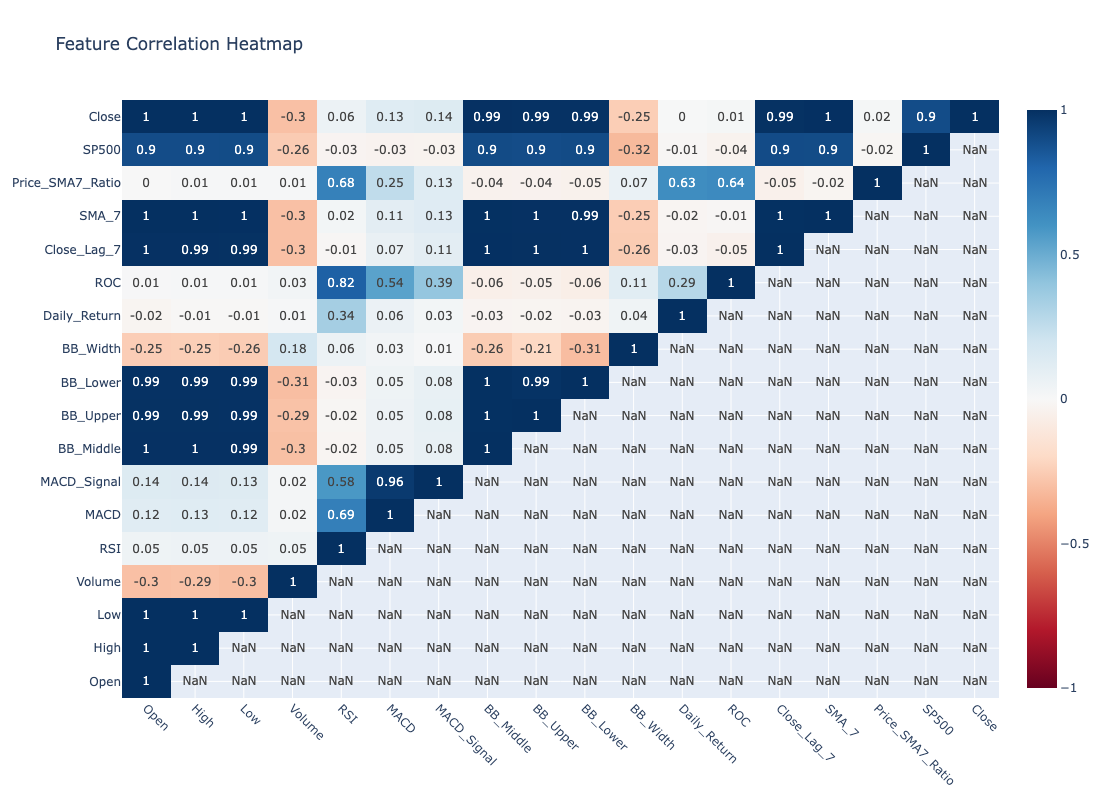

In [87]:
import plotly.graph_objects as go
import numpy as np

c=df[features+['Close']].corr()
c=c.mask(np.triu(np.ones_like(c,dtype=bool),1))

fig=go.Figure(go.Heatmap(z=c.values,x=c.columns,y=c.columns,
    text=np.round(c.values,2),texttemplate='%{text}',
    colorscale='RdBu',zmin=-1,zmax=1))
fig.update_layout(title='Feature Correlation Heatmap',
    width=1100,height=800,xaxis_tickangle=45)
fig.show()

## Short Report: Feature Correlation Analysis

### Observation:

Open, High, Low, SMA_7, and Close_Lag_7 show a very strong positive correlation (~0.99–1.00) with Bitcoin Close.   
S&P500 also has a strong positive correlation (0.90) with Close.   
Volume has a moderate negative correlation (-0.30) with Close.   
Technical indicators such as RSI, MACD, and ROC show relatively weaker direct correlation with Close.   
MACD and MACD_Signal are strongly correlated (0.96) with each other.   

### Conclusion
The correlation analysis shows that price-based features and S&P500 have strong relationships with Bitcoin’s closing price, while technical indicators provide additional but weaker information. These features together can help the LSTM model capture different aspects of Bitcoin price movement.

## Bitcoin Price Distribution

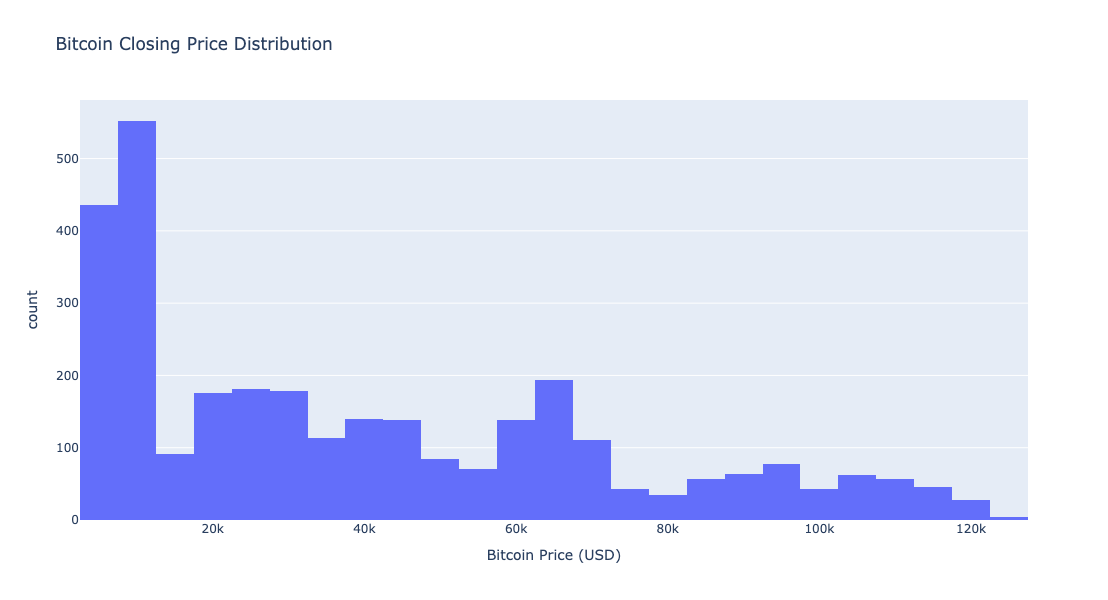

In [88]:
import plotly.express as px

fig=px.histogram(df,x='Close',nbins=50,
                 title='Bitcoin Closing Price Distribution',
                 labels={'Close':'Bitcoin Price (USD)','count':'Frequency'})
fig.update_layout(width=1100,height=600)
fig.show()

## Short Report — Bitcoin Closing Price Distribution

### Observation:
The histogram shows that Bitcoin’s closing prices are widely distributed, ranging from below 10,000USD  to above 120,000 USD. A large number of observations are concentrated in the lower price ranges, while fewer observations occur at very high prices.

### Conclusion:
The distribution indicates that Bitcoin’s price has increased significantly over time and shows high variability. The uneven distribution also reflects the strong price movements and volatility of Bitcoin.

##  Correlation between SP500 and Bitcoin price

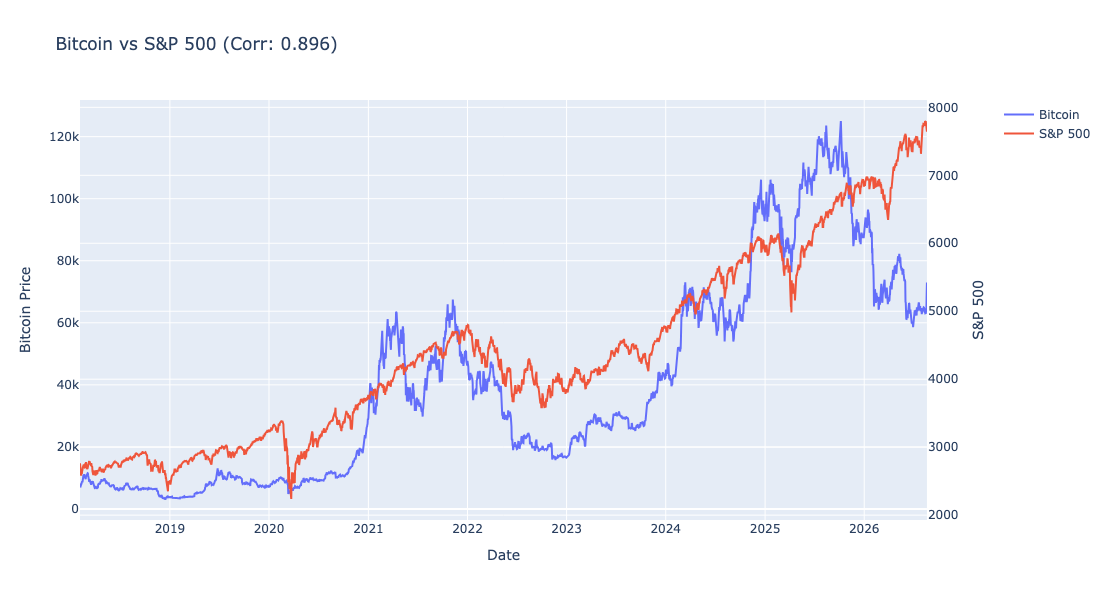

In [76]:

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=df.Date, y=df.Close, name='Bitcoin'), secondary_y=False)
fig.add_trace(go.Scatter(x=df.Date, y=df.SP500, name='S&P 500'), secondary_y=True)

fig.update_layout(
    title=f"Bitcoin vs S&P 500 (Corr: {df.Close.corr(df.SP500):.3f})",
    xaxis_title='Date', hovermode='x unified',
    width=1100, height=600
)

fig.update_yaxes(title_text='Bitcoin Price', secondary_y=False)
fig.update_yaxes(title_text='S&P 500', secondary_y=True)
fig.show()

## Correlation between VIX and Bitcoin price

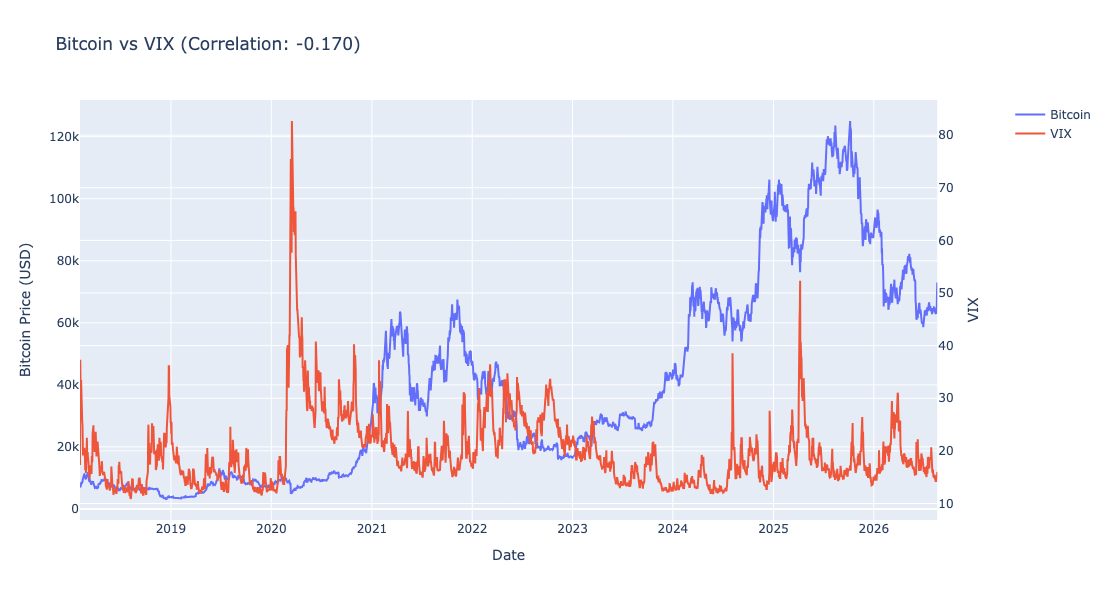

In [73]:
# # correlation between VIX and Bitcoin price

d=df[['Date','Close','VIX']].dropna()
f=make_subplots(specs=[[{"secondary_y":True}]])

f.add_trace(go.Scatter(x=d.Date,y=d.Close,name='Bitcoin'),secondary_y=False)
f.add_trace(go.Scatter(x=d.Date,y=d.VIX,name='VIX'),secondary_y=True)

c=d.Close.corr(d.VIX)
f.update_layout(title=f"Bitcoin vs VIX (Correlation: {c:.3f})",
                xaxis_title='Date',hovermode='x unified',
                width=1100,height=600)
f.update_yaxes(title_text='Bitcoin Price (USD)',secondary_y=False)
f.update_yaxes(title_text='VIX',secondary_y=True)
f.show()

## Correlation gold vs Bitcoin_price

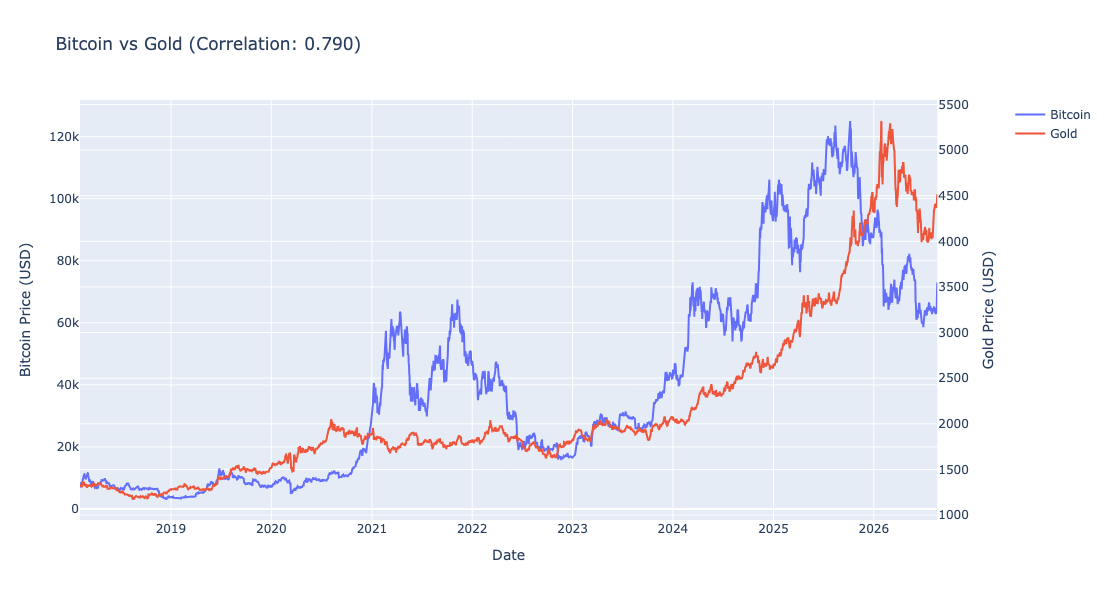

In [69]:
# Correlation gold vs Bitcoin_price

import plotly.graph_objects as go
from plotly.subplots import make_subplots

d=df[['Date','Close','Gold']].dropna()
f=make_subplots(specs=[[{"secondary_y":True}]])

f.add_trace(go.Scatter(x=d.Date,y=d.Close,name='Bitcoin'),secondary_y=False)
f.add_trace(go.Scatter(x=d.Date,y=d.Gold,name='Gold'),secondary_y=True)

c=d.Close.corr(d.Gold)
f.update_layout(title=f"Bitcoin vs Gold (Correlation: {c:.3f})",
                xaxis_title='Date',hovermode='x unified',
                width=1100,height=600)
f.update_yaxes(title_text='Bitcoin Price (USD)',secondary_y=False)
f.update_yaxes(title_text='Gold Price (USD)',secondary_y=True)
f.show()

In [78]:
df[['Close','Gold']].pct_change().corr().loc['Close','Gold']

0.09180921281965095

## Report 

“Bitcoin and Gold show a strong correlation of 0.790 in their price levels, but their daily returns have a weak correlation of only 0.092, indicating limited short-term co-movement.”

# Technical Indicator

In [39]:
# Adding new features

import ta

# Calculate Relative Strength Index (RSI)
df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

# Calculate Moving Average Convergence Divergence (MACD)
df['MACD'] = ta.trend.MACD(df['Close']).macd()
df['MACD_Signal'] = ta.trend.MACD(df['Close']).macd_signal()

# Calculate Bollinger Bands
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_Middle'] = bb.bollinger_mavg()
df['BB_Upper'] = bb.bollinger_hband()
df['BB_Lower'] = bb.bollinger_lband()
df['BB_Width'] = bb.bollinger_wband()

print("Technical indicators (RSI, MACD, Bollinger Bands) added to the DataFrame.")
print("New columns added:", ['RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width'])

# Display the head of the DataFrame with new indicators
display(df.tail())

Technical indicators (RSI, MACD, Bollinger Bands) added to the DataFrame.
New columns added: ['RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width']


,Open time,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,VIX,SP500,Gold,RSI,MACD,MACD_Signal,BB_Middle,BB_Upper,BB_Lower,BB_Width
3148,2026-08-16 00:00:00+00:00,63086.01,63390.00,62716.00,62900.00,4737.23135,2.986980e+08,640294,2498.03555,1.574978e+08,...,14.25,7785.759766,4380.399902,41.953029,-245.518292,-82.594770,63846.7015,65259.703232,62433.699768,4.426233
3149,2026-08-17 00:00:00+00:00,62900.00,64610.01,62751.10,64532.10,14255.64713,9.093661e+08,2111256,7186.91098,4.585080e+08,...,15.19,7745.060059,4417.799805,54.280978,-154.392920,-96.954400,63877.5565,65321.781917,62433.331083,4.521856
3150,2026-08-18 00:00:00+00:00,64532.11,65058.81,64027.85,64725.42,11789.91312,7.594053e+08,1608019,5759.24912,3.709881e+08,...,15.84,7691.759766,4366.000000,55.486885,-65.817397,-90.726999,63914.6135,65405.180738,62424.046262,4.664245
3151,2026-08-19 00:00:00+00:00,64725.42,70000.00,64166.00,69334.79,29054.29976,1.954769e+09,4160596,15646.86527,1.052899e+09,...,14.89,7707.979980,4489.399902,73.461087,372.028468,1.824094,64142.3520,66924.474997,61360.229003,8.674839
3152,2026-08-20 00:00:00+00:00,69334.78,73400.00,68902.22,73025.15,35904.79287,2.562054e+09,6249114,18144.94133,1.294797e+09,...,16.01,7641.160156,4516.299805,80.314652,1005.218152,202.502906,64649.2155,69358.636484,59939.794516,14.569151


# Checking for the missing features

In [41]:
required = [
    'Open', 'High', 'Low', 'Volume',
    'RSI', 'MACD', 'MACD_Signal',
    'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width',
    'Daily_Return', 'ROC',
    'Close_Lag_7', 'SMA_7', 'Price_SMA7_Ratio',
    'SP500'
]

missing = [x for x in required if x not in df.columns]

print("Missing features:", missing)
print("Total required:", len(required))

Missing features: ['Daily_Return', 'ROC', 'Close_Lag_7', 'SMA_7', 'Price_SMA7_Ratio']
Total required: 17


In [42]:
# Add additional required features

# Additional technical features

df['Daily_Return'] = df['Close'].pct_change()

df['ROC'] = ta.momentum.ROCIndicator(
    df['Close'], window=12
).roc()

df['Close_Lag_7'] = df['Close'].shift(7)

df['SMA_7'] = df['Close'].rolling(window=7).mean()

df['Price_SMA7_Ratio'] = df['Close'] / df['SMA_7']

# Remove rows created by lag/rolling calculations
df = df.dropna().reset_index(drop=True)

print("Missing features check:")
required = [
    'Open','High','Low','Volume',
    'RSI','MACD','MACD_Signal',
    'BB_Middle','BB_Upper','BB_Lower','BB_Width',
    'Daily_Return','ROC','Close_Lag_7',
    'SMA_7','Price_SMA7_Ratio','SP500'
]

print([x for x in required if x not in df.columns])
print("Total features:", len(required))

Missing features check:
[]
Total features: 17


# Scaling and 30 day sequence

In [43]:
import tensorflow as tf
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

In [44]:
def create_sequences(X, y, n_steps):
    X_seq, y_seq = [], []

    for i in range(n_steps, len(X)):
        X_seq.append(X[i-n_steps:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [45]:
features = [
    'Open', 'High', 'Low', 'Volume',
    'RSI', 'MACD', 'MACD_Signal',
    'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width',
    'Daily_Return', 'ROC',
    'Close_Lag_7', 'SMA_7', 'Price_SMA7_Ratio',
    'SP500'
]

df_model = df[features + ['Close']].dropna().copy()

data = df_model[features].values
target = df_model[['Close']].values

n_steps_in = 30
split = int(len(data) * 0.8)

# Scaling — training data only
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(data[:split])
scaler_y.fit(target[:split])

data_scaled = scaler_X.transform(data)
target_scaled = scaler_y.transform(target)

# Create sequences
X_train, y_train = create_sequences(
    data_scaled[:split],
    target_scaled[:split],
    n_steps_in
)

X_test, y_test = create_sequences(
    data_scaled[split - n_steps_in:],
    target_scaled[split - n_steps_in:],
    n_steps_in
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Features:", X_train.shape[2])

X_train: (2466, 30, 17)
X_test : (624, 30, 17)
y_train: (2466, 1)
y_test : (624, 1)
Features: 17


# Standalone LSTM Model

In [46]:
# Standalone LSTM Model

inp = Input(shape=(n_steps_in, X_train.shape[2]))

lstm = LSTM(128, activation='relu')(inp)
dense = Dense(64, activation='relu')(lstm)
drop = Dropout(0.2)(dense)
out = Dense(1)(drop)

lstm_model = Model(inp, out)

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse'
)

lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,073 (324.50 KB)

 Trainable params: 83,073 (324.50 KB)

 Non-trainable params: 0 (0.00 B)

# Training LSTM Model

In [47]:
# Lstm Training

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0257 - val_loss: 0.0079
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0245 - val_loss: 0.0018
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0069 - val_loss: 0.0025
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0027 - val_loss: 0.0034
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0031 - val_loss: 8.2401e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0022 - val_loss: 8.8457e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0025 - val_loss: 9.0891e-04
Epoch 9/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 10/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0020 - val_loss: 9.6497e-04
Epoch 11/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0017 - val_loss: 9.9590e-04
Epoch 12/200
31/31 ━━━━━━━━━━━━━

## Check for Overfitting 

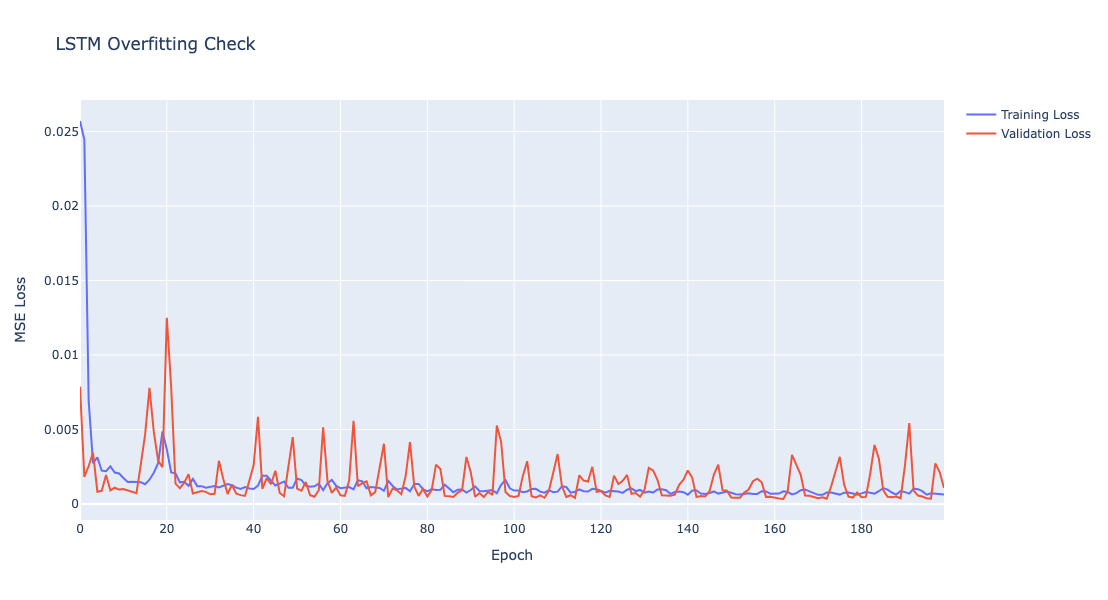

In [75]:
import plotly.graph_objects as go
f=go.Figure()
f.add_scatter(y=history.history['loss'],name='Training Loss')
f.add_scatter(y=history.history['val_loss'],name='Validation Loss')
f.update_layout(title='LSTM Overfitting Check',xaxis_title='Epoch',yaxis_title='MSE Loss',width=1100,height=600)
f.show()

## Prediction & Accuracy Test

In [48]:
# Standalone LSTM prediction on test set

y_pred_scaled = lstm_model.predict(X_test, verbose=0)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
)

y_actual = scaler_y.inverse_transform(y_test)

mape = mean_absolute_percentage_error(y_actual, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("Standalone LSTM Results")
print("=======================")
print(f"MAPE : {mape:.4f}%")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Standalone LSTM Results
MAPE : 6.2296%
RMSE : 5919.28
R²   : 0.8889


# Results

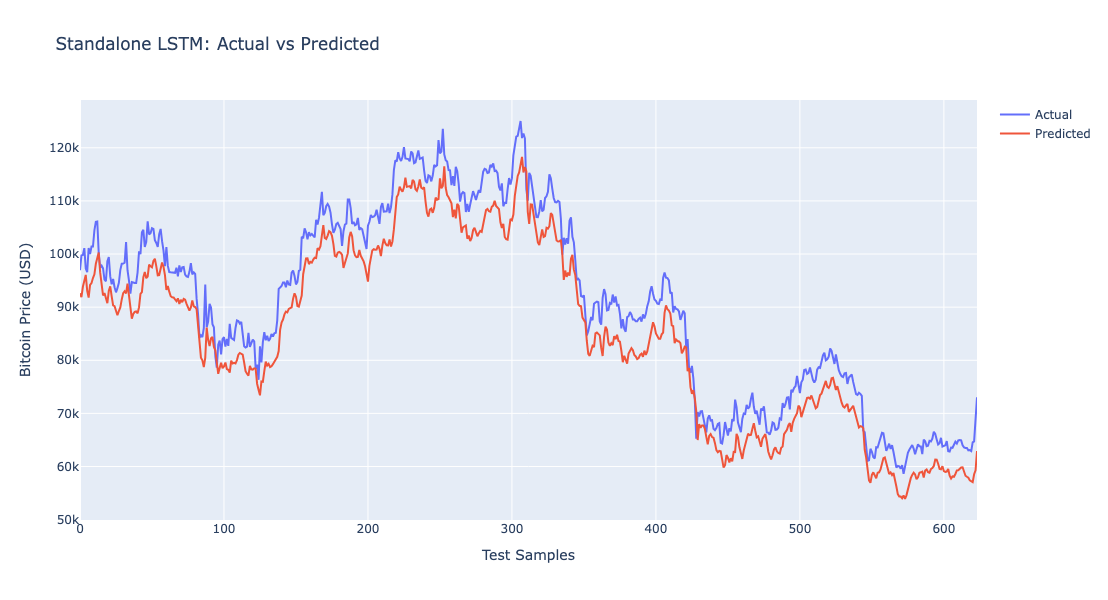

In [90]:
# Actual vs Predicted — Final Standalone LSTM
import plotly.graph_objects as go

y_actual = scaler_y.inverse_transform(y_test).flatten()
y_pred = scaler_y.inverse_transform(lstm_model.predict(X_test, verbose=0)).flatten()

go.Figure([
    go.Scatter(y=y_actual, name='Actual'),
    go.Scatter(y=y_pred, name='Predicted')
]).update_layout(
    title='Standalone LSTM: Actual vs Predicted',
    xaxis_title='Test Samples',
    yaxis_title='Bitcoin Price (USD)',
    width=1100, height=600
).show()

## Prediction Error / Residual Plot

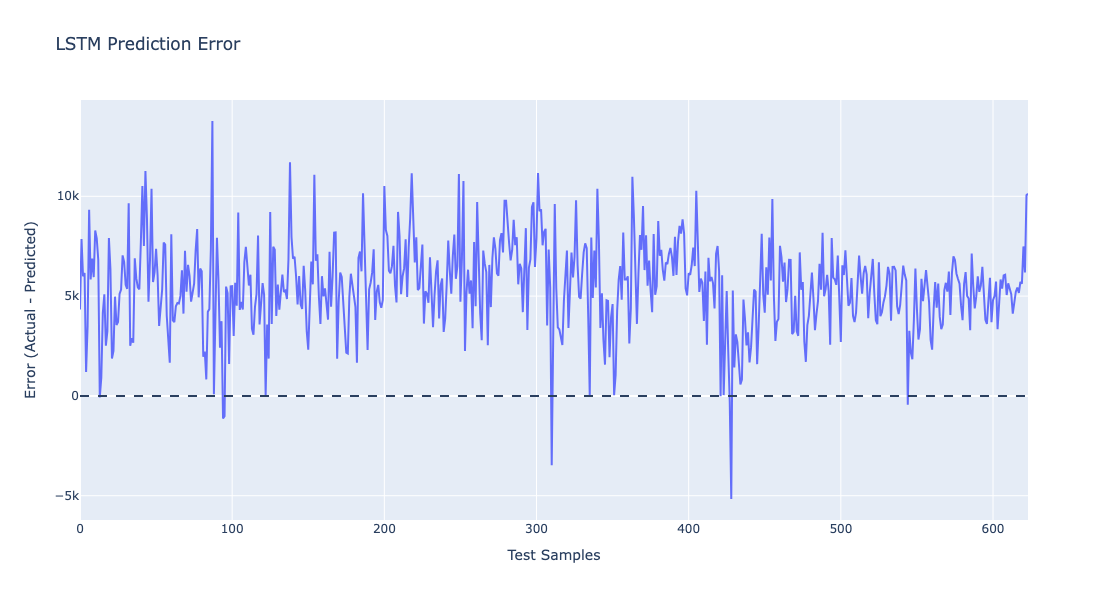

In [92]:
y_actual=scaler_y.inverse_transform(y_test).flatten()
y_pred=scaler_y.inverse_transform(lstm_model.predict(X_test,verbose=0)).flatten()
error=y_actual-y_pred

go.Figure(go.Scatter(y=error,mode='lines',name='Prediction Error')).update_layout(
    title='LSTM Prediction Error',
    xaxis_title='Test Samples',yaxis_title='Error (Actual - Predicted)',
    width=1100,height=600
).add_hline(y=0,line_dash='dash').show()

## Short Report — LSTM Prediction Error

### Observation:

Most errors are positive, meaning the LSTM generally underpredicts Bitcoin price.
Error is mostly around (3,000–7,000) USD, with some larger deviations.
A few negative errors show occasions where the model overpredicted.
Large spikes indicate the model struggles during periods of high price volatility.

### Conclusion:
The LSTM captures the general price pattern but has a noticeable underprediction bias and larger errors during volatile market conditions.

## Prediction Error Distribution

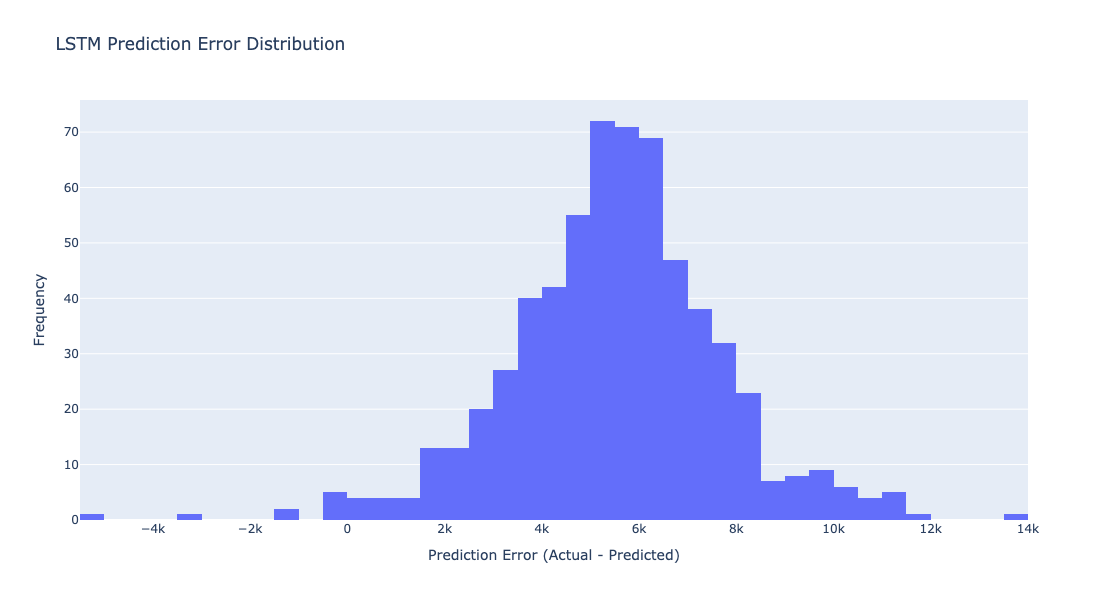

In [94]:
import plotly.graph_objects as go

y_test_actual = scaler_y.inverse_transform(y_test).flatten()
y_pred_actual = scaler_y.inverse_transform(
    lstm_model.predict(X_test, verbose=0)
).flatten()

error = y_test_actual - y_pred_actual

fig = go.Figure(go.Histogram(x=error, nbinsx=50))
fig.update_layout(
    title='LSTM Prediction Error Distribution',
    xaxis_title='Prediction Error (Actual - Predicted)',
    yaxis_title='Frequency',
    width=1100, height=600
)
fig.show()

## Short Report — LSTM Prediction Error Distribution

### Observation:

Most prediction errors lie between approximately (3,000–8,000) USD.
The distribution is concentrated on the positive side.
This indicates that the model generally underpredicts Bitcoin prices.
A few large errors occur on both sides, showing difficulty during unusual price movements.

### Conclusion:
The LSTM predictions have a systematic underprediction tendency. Improving the model or adding more informative features may help reduce this bias and large errors.

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : $5,537.18
RMSE : $5,919.28
R²   : 0.8889


# Model Evaluation

MAE = 5,537.18 USD→ model ki average prediction actual price se about $5.5K differ karti hai.    
RMSE = 5,919.28 USD → larger prediction errors bhi relatively controlled hain.   
R² = 0.8889 → model test data mein Bitcoin price variation ka approximately 88.89% explain karta hai.
Conclusion

The LSTM model demonstrates strong predictive performance with an R² score of 0.8889, although the MAE and RMSE indicate that prediction errors of around $5–6K remain.

# Final Prediction

In [66]:
latest_data = df[features].dropna().tail(n_steps_in)

latest_scaled = scaler_X.transform(latest_data)

X_future = latest_scaled.reshape(1, n_steps_in, len(features))

predicted_scaled = lstm_model.predict(X_future, verbose=0)

predicted_price = scaler_y.inverse_transform(
    predicted_scaled
)[0][0]


print("FINAL STANDALONE LSTM PREDICTION")

print(f"Prediction Date: 21 August 2026")
print(f"Predicted Bitcoin Price: ${predicted_price:,.2f}")


/opt/anaconda3/envs/bitcoin_tf/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


FINAL STANDALONE LSTM PREDICTION
Prediction Date: 21 August 2026
Predicted Bitcoin Price: $66,295.59


In [67]:
print(lstm_model)
print(xgb_model)

<Functional name=functional_1, built=True>
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


# XG Boost Model

In [99]:
# Extract LSTM features for XGBoost

extractor = Model(
    inputs=lstm_model.input,
    outputs=lstm_model.layers[1].output
)

z_train = extractor.predict(X_train, verbose=0)
z_test = extractor.predict(X_test, verbose=0)

print("z_train:", z_train.shape)
print("z_test :", z_test.shape)

z_train: (2466, 128)
z_test : (624, 128)


## Xg Boost Model Training

In [100]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=10,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(z_train, y_train.ravel())

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
## Test Accuracy Metric

In [106]:
# LSTM + XGBoost prediction on test set

y_actual = scaler_y.inverse_transform(y_test).flatten()

y_pred_scaled = xgb_model.predict(z_test)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

# Metrics
mape_xgb = mean_absolute_percentage_error(y_actual, y_pred) * 100
rmse_xgb = np.sqrt(mean_squared_error(y_actual, y_pred))
r2_xgb = r2_score(y_actual, y_pred)

print("LSTM + XGBoost Results")
print("======================")
print(f"MAPE : {mape_xgb:.4f}%")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R²   : {r2_xgb:.4f}")

LSTM + XGBoost Results
MAPE : 7.1935%
RMSE : 10174.23
R²   : 0.6718


## XGBoost Model Evaluation

XGBoost model was also tested as an alternative/hybrid approach using the features extracted from the LSTM model. However, its performance was lower than the standalone LSTM model.

Metric 	Standalone LSTM	   | LSTM + XGBoost         
MAPE -> 	4.35%	           | 7.19%            
RMSE -> 	5,211.90	       | 10,174.23          
R²	 ->   0.9138	           | 0.6718        
### Observation    

The standalone LSTM achieved a lower MAPE and RMSE and a higher R² score compared with the LSTM-XGBoost approach. Therefore, adding XGBoost did not improve the prediction performance.

### Conclusion

Although XGBoost was tested as a hybrid model, it produced inferior results compared with the standalone LSTM. Therefore, XGBoost was not selected as the final prediction model, and the standalone LSTM was chosen because of its better overall predictive performance.

# Final Prediction Code

In [107]:
latest_data = df[features].dropna().tail(n_steps_in)
latest_scaled = scaler_X.transform(latest_data)
X_future = latest_scaled.reshape(1,n_steps_in,len(features))

pred = scaler_y.inverse_transform(
    lstm_model.predict(X_future,verbose=0)
)[0][0]

print(f"Predicted Bitcoin Price: ${pred:,.2f}")

/opt/anaconda3/envs/bitcoin_tf/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Predicted Bitcoin Price: $66,295.59


# Final Results

Metric for	Standalone LSTM model            
MAE    -> 	5,537.18 USD          
RMSE   ->	5,919.28 USD            
R²	   ->   0.8889             

## Final Conclusion

The developed LSTM model achieved an R² score of 0.8889, indicating strong predictive performance on the test data. The model successfully captured the overall trend of Bitcoin prices, although prediction errors increased during highly volatile periods. The standalone LSTM performed better than the tested LSTM-XGBoost hybrid approach, making it the preferred final model for this project.